In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Geometric Brownian Motion (GBM)
Geometric Brownian Motion is a continuous-time stochastic process used in finance to model asset prices. I'll be real, "continuous-time stochastic process" is jargony, so I'll define this statement. There are two ways of treating time in math:
- Discrete Time: views values of variables as occurring at distinct, separate "points in time". Time is veiwed as a discrete varible. Think of a digital clock that is on 1:00 for a while and then moves to 1:01
- Continous time: views variables as having a particular value only for an infinitesimally short amount of time. Between any two points in time there are an infinite number of other points in time.

A stocastic process is a mathematical model used to describe a system that evolves over time in a random, unpredictable way.
We can use the following stochastic differential equation to use GBM to represent a stochastic process $S(t)$: $$dS(t) = \mu S(t)dt + \sigma S(t)dB(t)$$
Where:
- $S(t)$: The asset price, what we are solving for
- $\mu$: The percentage drift (constant)
- $\sigma$: the percentage volatility (constant)
- $B(t)$: represents the Brownian motion/Weiner process
To find the solution to the differential equation we have to use Ito's Lemma

## Ito's Lemma
Ito's Lemma is used to determine the derivative of a time-dependent function of a stochastic process. It was basically chain rule in a stochastic setting. But why can't you use the regular chain rule? Random paths (like Brownian motion) are continuous but non-differentiable. This leads to a problem because in the chain rule you must be able to calculate the exact rate of change ($\frac{dy}{du}$ and $\frac{du}{dx}$) for both functions. Consider the stochastic differential equation: $S(t)$: $$dS(t) = \mu S(t)dt + \sigma S(t)dB(t)$$
Now let $f(t, S(t))$ be a smooth function of time and $S(t)$. The Lemma is: $$df=\frac{\partial f}{\partial t}dt+\frac{\partial f}{\partial S}dS + \frac{1}{2}\frac{\partial^2 f}{\partial S^2}(dS)^2$$

## Using Ito's Lemma to find $S(t)$:
First we have to actually choose a function $f(t, S(t))$, it is customary to use $f(t, S(t)) = \ln(S)$ because it makes our math a lot easier for the following reasons:
- We can garentee prices don't go below $0$. Since $B(t)$ can go anywhere we could get negative $S(t)$, which makes no sense since asset prices don't go below zero
- Changes in real prices compound multiplicatively over time. By taking the logarithm of prices, you convert these multiplicative changes into additive changes, making the mathematics like calculating sums of variance over long timeframes much more manageable.
Now lets find the needed derivatives:
- $\frac{\partial f}{\partial t}=0$
- $\frac{\partial f}{\partial S}=\frac{1}{S}$
- $\frac{\partial^2 f}{\partial S^2}=-\frac{1}{S^2}$

When we apply Ito's Lemma remember the multiplication rules:
- $dt^2=0$
- $dt\times dB=0$
- $dB^2=dt$

Now sub into Ito Lemma: $$d(\ln(S))=\frac{1}{S}dS-\frac{1}{2}\frac{1}{S^2}(\sigma S(t)dB(t))^2=\frac{1}{S}dS-\frac{1}{2}\frac{1}{S^2}\sigma^2S^2dt$$
When subbing $dS$ in the first term goes to $0$ because $dt^2=0$

Now lets simplify: $$d(\ln(S))=\frac{1}{S}(\mu Sdt + \sigma S(t)dB) - \frac{\sigma^2}{2}dt=(\mu dt + \sigma dB) - \frac{\sigma^2}{2}dt$$
Rearrange equation: $$d(\ln(S))=\mu dt  - \frac{\sigma^2}{2}dt + \sigma dB=(\mu - \frac{\sigma^2}{2})dt+ \sigma dB$$
Now there is no $S$ on the right side anymore, now we can integrate on both sides: $$\int^t_0d(\ln(S))=\int^t_0(\mu - \frac{\sigma^2}{2})dt+ \sigma dB$$
Lets do some of the integrals: 
- $\int^t_0d(\ln(S))=\ln(S(t))-\ln(S(0))=\ln(\frac{S(t)}{S(0)})$
- $\int^t_0(\mu - \frac{\sigma^2}{2})dt=(\mu - \frac{\sigma^2}{2})t$
- $\int^t_0\sigma dB=\sigma(B(t)-B(0))$, since $B(0)$ customarily: $\sigma B(t)$

Sub everything in: $$\ln(\frac{S(t)}{S(0)}) = (\mu - \frac{\sigma^2}{2})t + \sigma B(t)$$
Now exponentiate both sides: $$e^{\ln(\frac{S(t)}{S(0)})}=e^{(\mu - \frac{\sigma^2}{2})t + \sigma B(t)}=\frac{S(t)}{S(0)}=\exp((\mu - \frac{\sigma^2}{2})t + \sigma B(t))$$
So we found that: $$S(t)=S_0\exp((\mu - \frac{\sigma^2}{2})t + \sigma B(t))$$
This $B(t)$ term corresponds to the following: $$B(t+\Delta t)=B(t)+\sqrt{\Delta t}Z$$
Where: $Z \approx N(0,1)$

Text(0, 0.5, 'B(t)')

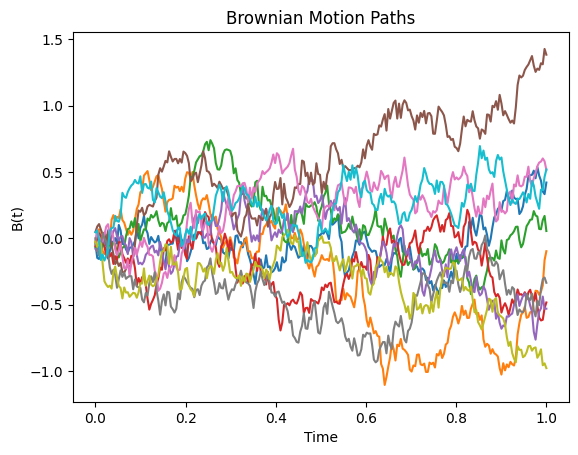

In [2]:
# Generate 10 random brownian paths
T = 1
N = 252
dt = T/N

time = np.linspace(0,T,N)

for i in range(10):
    dB = np.sqrt(dt) * np.random.normal(size=N)
    B = np.cumsum(dB)
    
    plt.plot(time, B)

plt.title("Brownian Motion Paths")
plt.xlabel("Time")
plt.ylabel("B(t)")

In [3]:
# Check varience, theory says that var(B(t)) = T
B = np.cumsum(np.sqrt(dt)*np.random.normal(size=N))

print(np.var(B))
print(T)

0.2636191646596592
1


True


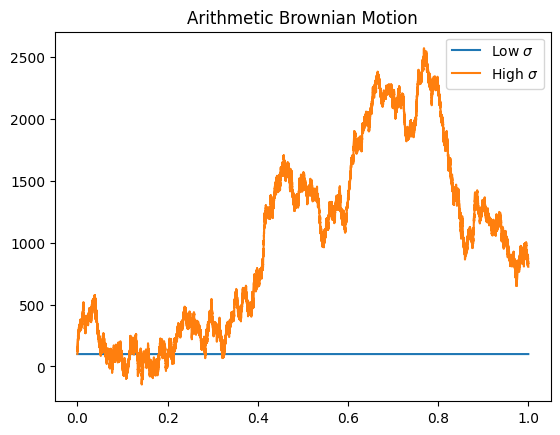

In [4]:
# Ok but why cant we use regular returns instead of log returns? Let's play with our volitility

T = 1
N = 252*1000
dt = T/N

time = np.linspace(0,T,N)
B = np.cumsum(np.sqrt(dt)*np.random.normal(size=N))

S0 = 100
mu = 0.1
sigma = 0.2
S_bad = S0 + mu*time + sigma*B

plt.plot(time,S_bad, label="Low $\sigma$")

S0 = 100
mu = 0.1
sigma = 1500
S_bad = S0 + mu*time + sigma*B

plt.plot(time,S_bad, label="High $\sigma$")
plt.title("Arithmetic Brownian Motion")
plt.legend()

has_negative = any(x < 0 for x in S_bad)

print(has_negative)

# We find that if our volitility is too high we can get negative returns which is impossible

Text(0, 0.5, 'Price')

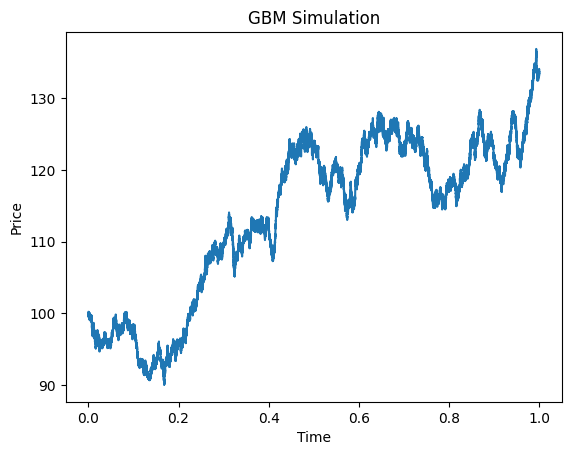

In [5]:
# Use our solution derived before using ln(S(t)) to see GBM

S0 = 100
mu = 0.1
sigma = 0.2

T = 1
N = 252*1000
dt = T/N

time = np.linspace(0,T,N)
B = np.cumsum(np.sqrt(dt)*np.random.normal(size=N))

S = S0*np.exp((mu-0.5*sigma**2)*time + sigma*B)

plt.plot(time,S)
plt.title("GBM Simulation")
plt.xlabel("Time")
plt.ylabel("Price")

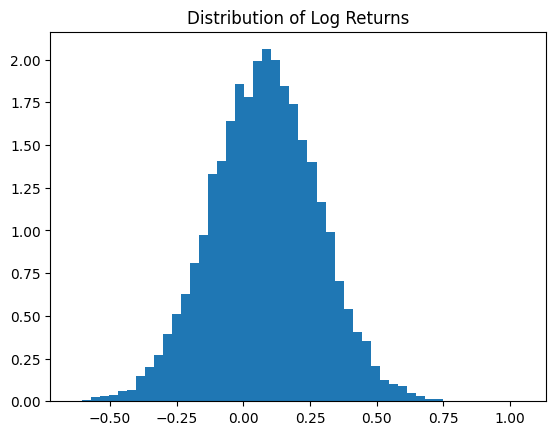

In [6]:
# We need to verify our log returns, if we did everything right we should see a Guassian

samples = []

for i in range(10000):
    B_T = np.sqrt(T)*np.random.normal()
    
    ST = S0*np.exp(
        (mu-.5*sigma**2)*T
        +sigma*B_T
    )
    
    samples.append(np.log(ST/S0))


plt.hist(samples,bins=50,density=True)
plt.title("Distribution of Log Returns")
plt.show()

Text(0.5, 1.0, 'Possible Future Prices')

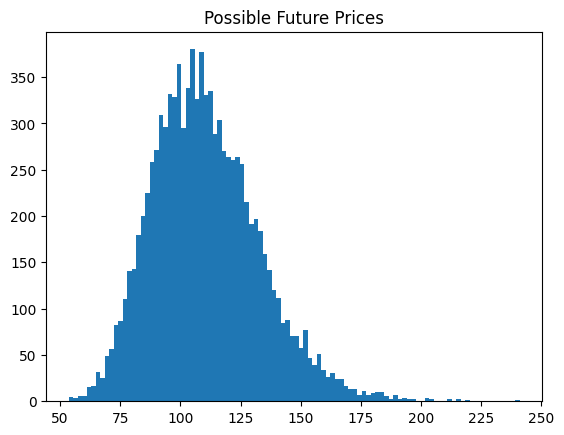

In [7]:
# Monte Carlo stock simulator
# Make 10,000 possible futures
# Show the lognormal distribution of prices

paths = 10000

final_prices=[]

for i in range(paths):

    B=np.sqrt(T)*np.random.normal()

    ST=S0*np.exp(
        (mu-.5*sigma**2)*T
        +sigma*B
    )

    final_prices.append(ST)


plt.hist(final_prices,bins=100)
plt.title("Possible Future Prices")

# Black Scholes Model
Black Scholes is used to find the fair price of a European option on $S(t)$ assuming that the underlying asset price follows Geometric Brownian Motion (GBM). This can be a little confusing so here are the differences between the two:

- GBM describes how the stock price moves over time
- Black Scholes describes how the option price changes based on the movement of the stock

The goal of Black-Scholes is to determine what is the fair price of the option today given:

- the current stock price
- the strike price
- time until expiration
- volatility
- risk-free interest rate

## Why do we need Black-Scholes?

A European option gives the holder the right (but not the obligation) to buy or sell an asset at a future time.
For a European call option:

$$\text{Payoff} = \max(S_T - K, 0)$$

Where:

- $S_T$: stock price at expiration
- $K$: strike price

The problem is that $S_T$ is random because the stock follows GBM. We need a way to calculate the expected value of this random payoff.

## Applying Ito's Lemma to the Option Price

Since the option value depends on both time and stock price:

$$V = V(t, S)$$

we apply Ito's Lemma:

$$dV = \frac{\partial V}{\partial t}dt + \frac{\partial V}{\partial S}dS + \frac{1}{2}\frac{\partial^2 V}{\partial S^2}(dS)^2$$

Substitute GBM:

$$dS = \mu S \, dt + \sigma S \, dB$$

and remember:

$$(dB)^2 = dt$$

The result becomes:

$$dV = \left(\frac{\partial V}{\partial t} + \mu S \frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}\right)dt + \sigma S \frac{\partial V}{\partial S} \, dB$$

Notice there is still a random Brownian motion term:

$$\sigma S \frac{\partial V}{\partial S} \, dB$$

This means the option price is also random.

## The Black-Scholes Idea: Remove Risk

The key idea is to create a portfolio containing:

- some amount of stock
- some amount of option

so that the random Brownian motion term cancels.

Create:

$$\Pi = V - \Delta S$$

where:

$$\Delta = \frac{\partial V}{\partial S}$$

is the option's sensitivity to the stock price. After choosing this portfolio, the randomness disappears, meaning the portfolio becomes risk-free.

A risk-free portfolio must earn the risk-free rate:

$$d\Pi = r\Pi \, dt$$

where $r$ is the risk-free interest rate. This leads to the Black-Scholes PDE:

$$\frac{\partial V}{\partial t} + rS \frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} - rV = 0$$

## Black-Scholes Formula

Solving the PDE gives the famous European call option price:

$$C = S_0 N(d_1) - K e^{-rT} N(d_2)$$

where:

$$d_1 = \frac{\ln(S_0/K) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}$$

$$d_2 = d_1 - \sigma\sqrt{T}$$

Where:

- $N(x)$: cumulative standard normal distribution
- $S_0$: current stock price
- $K$: strike price
- $T$: time until expiration
- $r$: risk-free rate
- $\sigma$: volatility

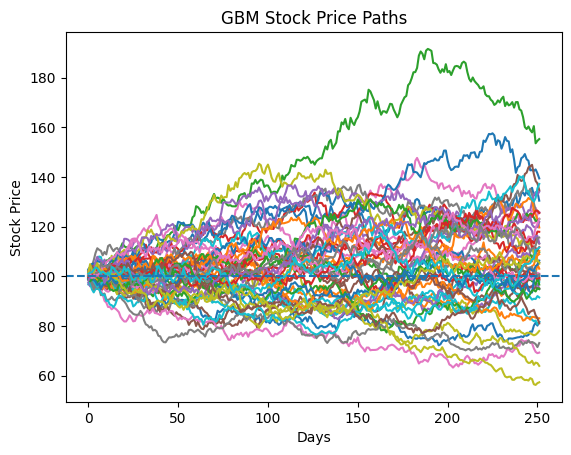

In [12]:
# visualize GBM paths and option payoff

S0 = 100
r = 0.05
sigma = 0.2
T = 1

N = 252
dt = T/N

paths = 50

for i in range(paths):
    B = np.cumsum(np.sqrt(dt)*np.random.normal(size=N))
    
    S = S0*np.exp((r-0.5*sigma**2)*np.linspace(0,T,N)+sigma*B)
    
    plt.plot(S)

plt.axhline(100, linestyle="--")
plt.title("GBM Stock Price Paths")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.show()

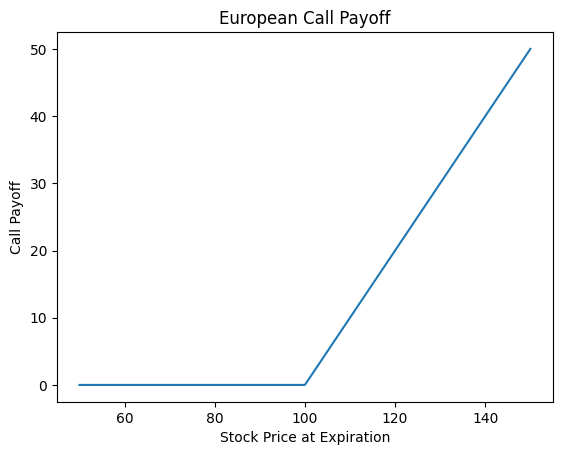

In [13]:
# Plot the European call payoff

S = np.linspace(50,150,500)

K = 100

payoff = np.maximum(S-K,0)

plt.plot(S,payoff)
plt.xlabel("Stock Price at Expiration")
plt.ylabel("Call Payoff")
plt.title("European Call Payoff")
plt.show()

In [10]:
# Monte Carlo Black-Scholes pricing
# generate thousands of possible futures to find price

S0=100
K=100
r=0.05
sigma=0.2
T=1

N=100000

Z=np.random.normal(size=N)

ST=S0*np.exp((r-.5*sigma**2)*T+sigma*np.sqrt(T)*Z)

payoff=np.maximum(ST-K,0)
price=np.exp(-r*T)*np.mean(payoff)

print(price)

10.504246887533116


In [22]:
from scipy.stats import norm


d1 = (
    np.log(S0/K)
    +(r+sigma**2/2)*T
)/(sigma*np.sqrt(T))


d2=d1-sigma*np.sqrt(T)


BS_price = (
    S0*norm.cdf(d1)
    -K*np.exp(-r*T)*norm.cdf(d2)
)


print("Monte Carlo:", price)
print("Black Scholes:", BS_price)

Monte Carlo: 10.504246887533116
Black Scholes: 54.970140137999195


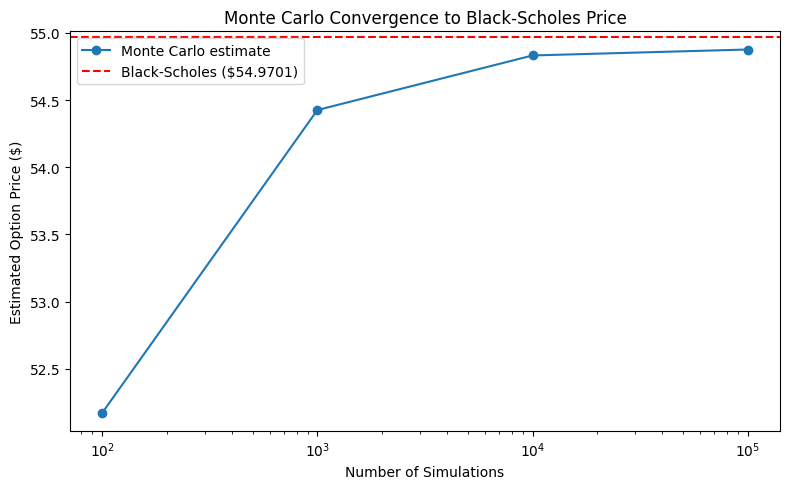

In [23]:
SIZES = [100, 1000, 10000, 100000]
RNG = np.random.default_rng(seed=42)

mc_prices = []
for n in SIZES:
    Z = RNG.standard_normal(n)
    S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(S_T - K, 0)
    mc_prices.append(np.exp(-r * T) * payoff.mean())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(SIZES, mc_prices, marker="o", label="Monte Carlo estimate")
ax.axhline(BS_price, linestyle="--", color="red", label=f"Black-Scholes (${BS_price:.4f})")
ax.set_xscale("log")
ax.set_xlabel("Number of Simulations")
ax.set_ylabel("Estimated Option Price ($)")
ax.set_title("Monte Carlo Convergence to Black-Scholes Price")
ax.legend()
plt.tight_layout()
plt.show()

In the plot above we can see that if we increase the number of simulations we wil find that our GBM/Monte Carlo method converges to the Black Scholes closed form solution, which means we are doing everything right

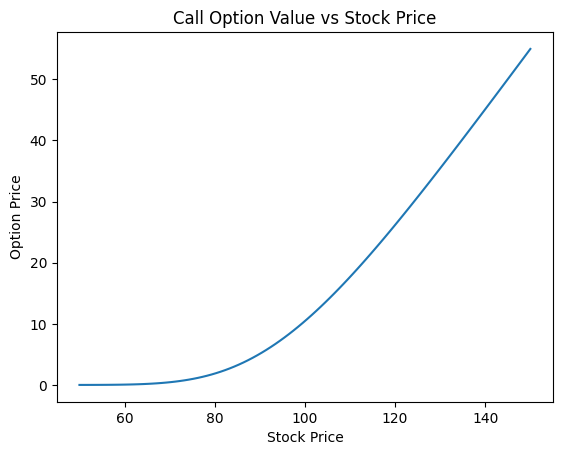

In [17]:
# Plot option price vs stock price (Delta)

stocks=np.linspace(50,150,100)

prices=[]


for S0 in stocks:

    d1=(np.log(S0/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
    d2=d1-sigma*np.sqrt(T)

    C=S0*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)

    prices.append(C)


plt.plot(stocks,prices)

plt.xlabel("Stock Price")
plt.ylabel("Option Price")

plt.title("Call Option Value vs Stock Price")

plt.show()